In [10]:
########################################
# Step-1: Inspect Data Types & Summary
########################################

import pandas as pd

# Load datasets
df1 = pd.read_csv("Sales_1.csv")
df2 = pd.read_csv("Sales_2.csv")

# Column types
print(df1.dtypes)
print(df2.dtypes)

# Descriptive statistics
print(df1.describe(include='all'))
print(df2.describe(include='all'))

Retailer            object
Product ID          object
City                object
Category            object
Price per Unit      object
Units Sold          object
Total Sales         object
Operating Profit    object
Operating Margin    object
dtype: object
Row ID             int64
Ship Mode         object
Customer ID       object
Customer Name     object
Country           object
City              object
Postal Code      float64
Product ID        object
Category          object
Product Name      object
Sales Price      float64
dtype: object
           Retailer       Product ID      City               Category  \
count          9648             9800      9648                   9648   
unique            6             1861        52                      6   
top     Foot Locker  OFF-PA-10001970  Portland  Men's Street Footwear   
freq           2637               19       360                   1610   

       Price per Unit Units Sold Total Sales Operating Profit Operating Margin  
count  

In [11]:
#############################################
# Step-2: Identify Missing & Unique Values
#############################################

# Percentage missing values
missing_percentage_df1 = df1.isnull().mean() * 100
missing_percentage_df2 = df2.isnull().mean() * 100

print("Missing % per column in Sales_1:\n", missing_percentage_df1)
print("\nMissing % per column in Sales_2:\n", missing_percentage_df2)

# Unique values in categorical columns
for col in df1.select_dtypes(include='object'):
    print(f"{col} unique values:\n{df1[col].unique()}")

for col in df2.select_dtypes(include='object'):
    print(f"{col} unique values:\n{df2[col].unique()}")

Missing % per column in Sales_1:
 Retailer            1.55102
Product ID          0.00000
City                1.55102
Category            1.55102
Price per Unit      1.55102
Units Sold          1.55102
Total Sales         1.55102
Operating Profit    1.55102
Operating Margin    1.55102
dtype: float64

Missing % per column in Sales_2:
 Row ID           0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Country          0.000000
City             0.000000
Postal Code      0.112245
Product ID       0.000000
Category         0.000000
Product Name     0.000000
Sales Price      0.000000
dtype: float64
Retailer unique values:
['Foot Locker' 'Walmart' 'Sports Direct' 'West Gear' "Kohl's" 'Amazon' nan]
Product ID unique values:
['FUR-BO-10001798' 'FUR-CH-10000454' 'OFF-LA-10000240' ...
 'TEC-MA-10003589' 'OFF-AP-10003099' 'TEC-PH-10002645']
City unique values:
['New York' 'Houston' 'San Francisco' 'Los Angeles' 'Chicago' 'Dallas'
 'Philadelphia' 'Las Vegas' 'De

In [20]:
#############################################
# Step-3: Explore Data from Multiple Sources
#############################################

# Combine vertically (stack rows)
df_combined = pd.concat([df1, df2], ignore_index=True)

# Combine horizontally (if common column exists)
df_merged = pd.merge(df1, df2, on='Product ID', how='inner')

print("Combined Shape:", df_combined.shape)
print("Combine vertically and horizontally are successfull...")

Combined Shape: (19600, 17)
Combine vertically and horizontally are successfull...


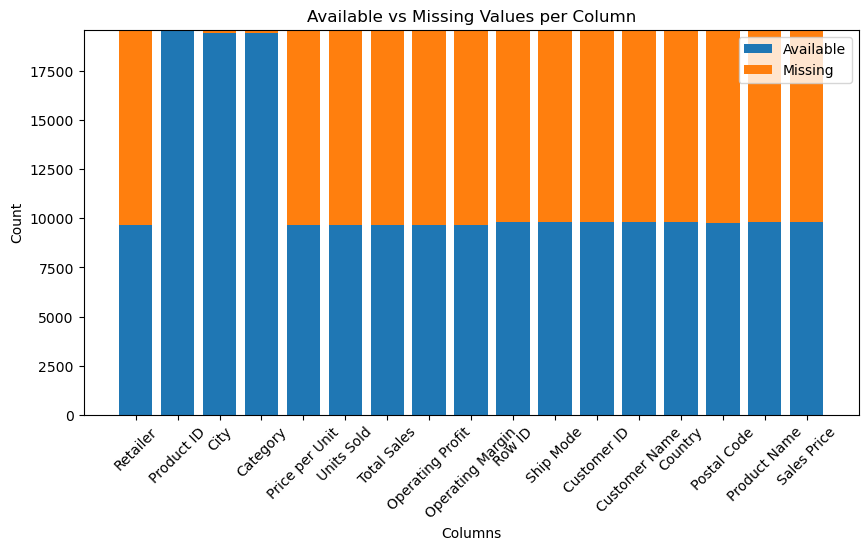

In [27]:
#############################################
# Step-4: Visualize Missing Patterns
#############################################

import matplotlib.pyplot as plt

# count missing and non-missing values
missing_count = df_combined.isnull().sum()
available_count = df_combined.notnull().sum()

# stacked bar graph
plt.figure(figsize=(10,5))

plt.bar(df_combined.columns, available_count, label="Available")
plt.bar(df_combined.columns, missing_count, bottom=available_count, label="Missing")

plt.title("Available vs Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.legend()

plt.show()

Retailer
Foot Locker      27.332090
West Gear        24.606136
Sports Direct    21.061360
Kohl's           10.675788
Amazon            9.836235
Walmart           6.488391
Name: proportion, dtype: float64
Product ID
OFF-PA-10001970    0.193878
TEC-AC-10003832    0.183673
FUR-FU-10004270    0.163265
TEC-AC-10002049    0.153061
TEC-AC-10003628    0.153061
                     ...   
OFF-PA-10000919    0.010204
TEC-MA-10003353    0.010204
OFF-LA-10003388    0.010204
OFF-EN-10004206    0.010204
TEC-PH-10002645    0.010204
Name: proportion, Length: 1861, dtype: float64
City
Los Angeles      4.853970
New York City    4.581448
Philadelphia     3.846154
San Francisco    3.681613
Houston          3.033731
                   ...   
Lindenhurst      0.005142
Abilene          0.005142
Normal           0.005142
Redding          0.005142
Springdale       0.005142
Name: proportion, Length: 539, dtype: float64
Category
Office Supplies              30.383587
Furniture                    10.684903
Techno

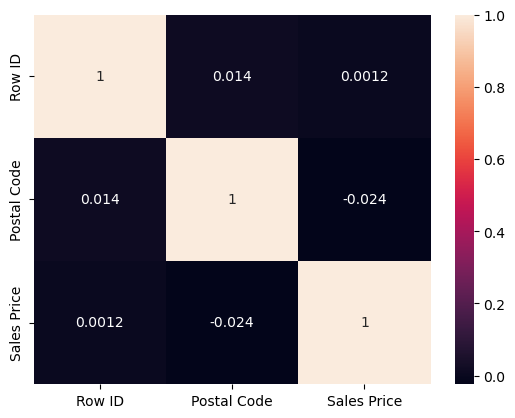

In [22]:
##################################################
# Step-5: Summary Statistics for Characterization
##################################################

import seaborn as sns

# Categorical column distribution
for col in df_combined.select_dtypes(include='object'):
    print(df_combined[col].value_counts(normalize=True) * 100)

# Correlation matrix for numerical columns
print(df_combined.corr(numeric_only=True))

sns.heatmap(df_combined.corr(numeric_only=True), annot=True)
plt.show()